Goal: compare average diurnal cycle of dT/dz with depth for different surface IDs

Code largely from Raven_surface_comparisons.ipynb

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from scipy import interpolate
import scipy.signal
from datetime import datetime as dt
import cmocean
import datetime
from matplotlib.dates import DateFormatter
import glob
# import math
# from astropy.convolution import convolve
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib as mpl
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
import pandas as pd
import csv
myFmt = mdates.DateFormatter('%m-%d')

from ICECAPS_support_functions import *

### Write more functions

In [25]:
def datetimes_to_seconds(dates_in):
    """ convert datetime objects to seconds since 1970/1/1 (arbitrary)
    dates_in should be a list or array of datetime object
    """
    seconds_out = np.asarray([(t-dt(1970,1,1)).total_seconds() for t in dates_in])
    return seconds_out

In [89]:
def open_simba_sfc_file(file_version):
    acceptable_file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2',
                               'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0',
                               'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
                               'v4.2_20250730_sfcdif+4.0_ksi20.0', 'v4.2_20250730_sfcdif+4.0_ksi15.0',
                               'v4.2_20250730_sfcdif+6.0_ksi15.0']

    if file_version not in acceptable_file_versions:
        print("Please choose of these versions: ", acceptable_file_versions)
        return

    if 'v4.' in file_version:
        fv_name = file_version[:13]
    else:
        fv_name = file_version[:11]
    sfc_fname = f'Raven2024_SIMBA_sfc_id_centered-smoothed-24hrolling-dTdz-variance_{fv_name}.csv'

    df = pd.read_csv('/home/asledd/ICECAPS/'+sfc_fname)
    simba_sfc_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['datetime'].values])       
    simba_sfc_in = df['surface [cm]'].values

    return simba_sfc_dates, simba_sfc_in

In [90]:
def open_corrected_simba_temps(file_version):
    acceptable_file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2',
                               'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0',
                               'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
                               'v4.2_20250730_sfcdif+4.0_ksi20.0', 'v4.2_20250730_sfcdif+4.0_ksi15.0',
                               'v4.2_20250730_sfcdif+6.0_ksi15.0']

    if file_version not in acceptable_file_versions:
        print("Please choose of these versions: ", acceptable_file_versions)
        return 

    if file_version=='v2_20250723':
        fn = '/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc_created_20250722.nc'
    elif 'v4.1_' in file_version:
        #fn = f'firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250729.nc'
        fn = f'/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250729.nc'
    elif 'v4_' in file_version:
        fn = f'/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250726.nc'
    elif 'v4.2_' in file_version:
        fn = f'/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250730.nc'
    else:
        fn = f'/home/asledd/ICECAPS/firnprofile_solar-correction_rolling-variance-max-sfc-{file_version}_created_20250725.nc'
    season_data_solar = {}
    
    varnames = ['temp','initial_height','time']
    fdic = load_netcdf(fn, varnames)
    
    fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
    season_data_solar['seconds'] = fdic['time']
    
    for varout, varin in zip(['temperature','dates','height'],['temp', 'dates','initial_height']):
        season_data_solar[varout] = fdic[varin]
    

    return season_data_solar

In [28]:
def interpolate_and_mask(var_data, var_secs, goal_secs):
    """
    interpolate var_data to have same time steps as goal_secs; mask data outside of bounds
    """
    f_var = interpolate.interp1d(var_secs, var_data, fill_value=-999, bounds_error=False)
    interped_var = f_var(goal_secs)
    interped_var = np.ma.masked_equal(interped_var, -999)
    return interped_var

In [29]:
def make_temps_rel_to_sfc(heights_rel_to_simba, temps_rel_to_simba, sfc_rel_to_simba):

    depths_rel_to_sfc = np.repeat(heights_rel_to_simba.copy()[np.newaxis,:], temps_rel_to_simba.shape[0], axis=0)
    sfc_2d = np.ma.repeat(sfc_rel_to_simba[:,np.newaxis], temps_rel_to_simba.shape[1], axis=1)
    depths_rel_to_sfc = depths_rel_to_sfc-sfc_2d


    temporary_temp = np.ma.masked_where(depths_rel_to_sfc>0, temps_rel_to_simba) # temporary temperature that's only at or below the surface

    m = 100. # I don't remember why this is 100!
    temps_rel_to_sfc = []
    
    for i in range(temporary_temp.shape[0]):
        temp_i = temporary_temp[i,:-1]
        sub_t = temp_i[~temp_i.mask]
    
        sub_t_filled = np.ma.concatenate( (sub_t, np.full(int(m-sub_t.count()), -999 )) )
        temps_rel_to_sfc.append(sub_t_filled)
        
    temps_rel_to_sfc = np.ma.masked_equal(temps_rel_to_sfc, -999)

    ## new height variable that decreases downward
    sub_depths = np.arange(0,temps_rel_to_sfc.shape[1])
    sub_depths *= -2

    return sub_depths, np.ma.masked_invalid(temps_rel_to_sfc)

In [30]:
def get_simba_time_of_day(dates_in):
    simba_hours = np.array([d.hour for d in dates_in])
    simba_mins = np.array([d.minute for d in dates_in])
    
    ## time of day
    simba_tod = simba_hours+simba_mins/60.
    
    return simba_tod

In [31]:
def get_diurnal_cycle(dates_in, data_in, stat='mean'):
    
    tod = get_simba_time_of_day(dates_in)
    if stat=='mean':
        daily_data_out = np.array([data_in[np.where(tod==t)[0],:].mean(axis=0) for t in np.unique(tod)])
    elif stat=='std':
        daily_data_out = np.array([data_in[np.where(tod==t)[0],:].std(axis=0) for t in np.unique(tod)])

    return daily_data_out

In [32]:
def load_uncorrected_simba():
    simba_filepath = '/psd3data/arctic/sledd/Raven_simba/'
    fn = 'firnprofile-combined-corrected-at38.sled.level2.beta.15min.20240517-20240821_created_June26_2025.nc'
    
    season_data_unc = {}
    if 'firnprofile-combined-corrected' in fn:
        varnames = ['temperature','initial_height','time']
        fdic = load_netcdf(simba_filepath+fn, varnames)
    else:
        varnames = ['temp','initial_height','time']
        fdic = load_netcdf(fn, varnames)
    
    if 'firnprofile-combined-corrected' in fn:
        fstart_time = datetime.datetime.strptime(fdic['time_unit'], 'minutes since %Y-%m-%d')
        fdic['dates'] = np.asarray([fstart_time+datetime.timedelta(minutes=int(m)) for m in fdic['time']])
    else:    
        fdic['dates'] = np.asarray([datetime.datetime(1970,1,1)+datetime.timedelta(seconds=int(s)) for s in fdic['time']])
    season_data_unc['seconds'] = fdic['time']
    
    for var in ['temperature','dates','initial_height']:
        if var=='temperature' and fn=='firnprofile_maxheight_solar-correction_created_20250417.nc':
            season_data_unc['temperature'] = fdic['temp']
        else:
            season_data_unc[var] = fdic[var]
    
    if 'firnprofile-combined-corrected' in fn:
        season_data_unc['height'] = season_data_unc['initial_height'][::-1]
        season_data_unc['temperature'] = season_data_unc['temperature'][:,::-1]
    else:
        season_data_unc['height'] = season_data_unc['initial_height']
        
    return season_data_unc

### Start loading in data and plotting


#### testing functions work

In [6]:
fversion = 'v2_20250723'

In [10]:
simba_data = open_corrected_simba_temps(fversion)
sfc_dates, sfc_data = open_simba_sfc_file(fversion)

sfc_seconds = datetimes_to_seconds(sfc_dates)
simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                     
simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

In [11]:
depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])

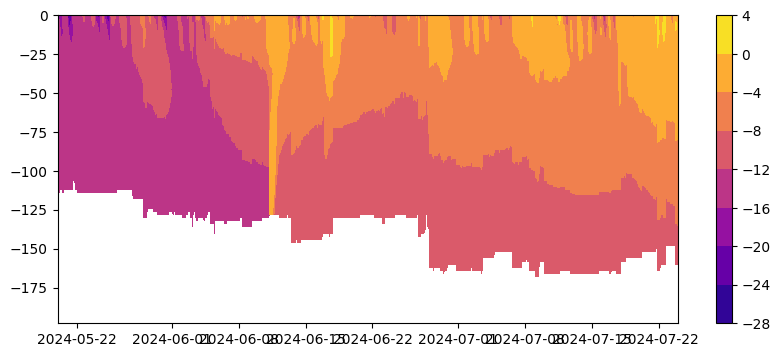

In [12]:
fig, axs = plt.subplots(1, figsize=(10,4))

cb = plt.contourf(simba_data['dates'], depth_rel_sfc, np.swapaxes(temps_rel_sfc,0,1), cmap='plasma')
# plt.plot(simba_dates, simba_sfc-6.,  c='k')
plt.colorbar(cb)

# plt.xlim(dt(2024,6,8),dt(2024,6,15))
plt.show()

In [13]:
dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

In [14]:
avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

In [15]:
plt_tod = get_simba_time_of_day(simba_data['dates'])

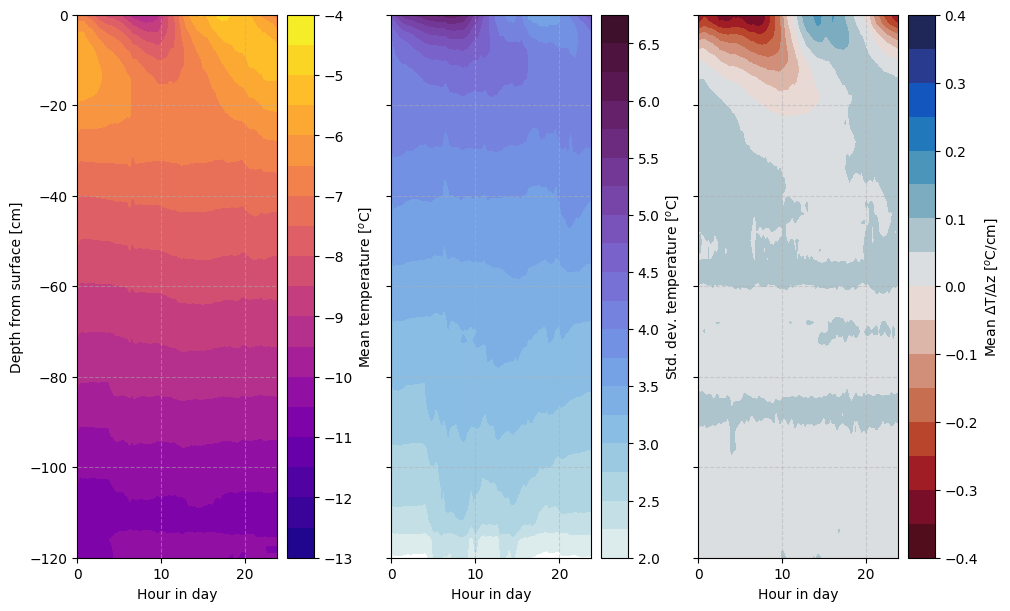

In [16]:
fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)

cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance_r]

for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_T, std_diurnal_T, avg_diurnal_dTdz])):
    cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
    plt.colorbar(cb, label=cbar_labels[i], ax=ax)

    ax.set_ylim(-120,0)
    
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')

axs[0].set_ylabel('Depth from surface [cm]')
# plt.tight_layout()
plt.show()

#### Loop over all the files I'm interested in

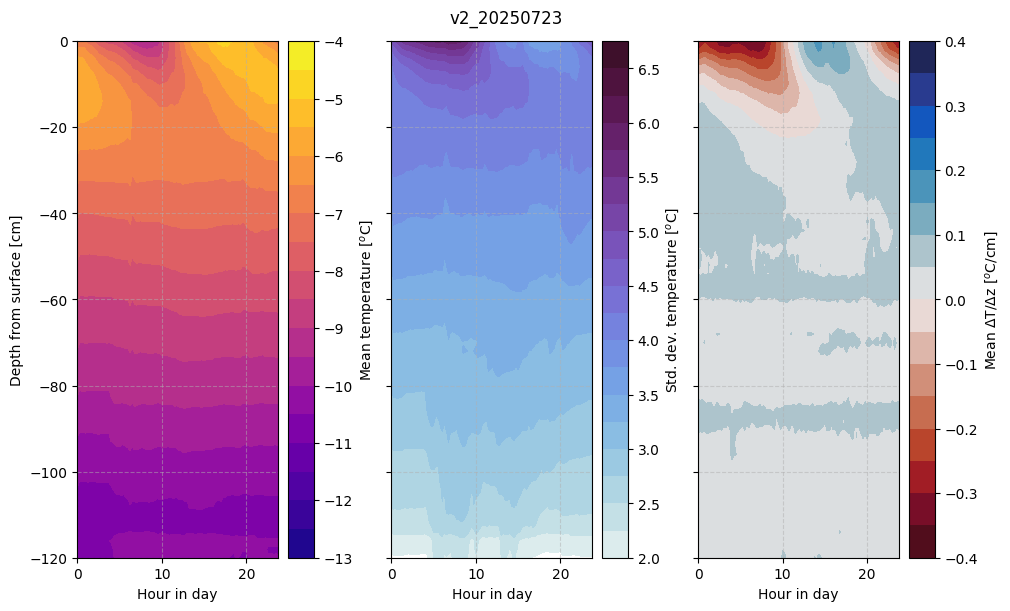

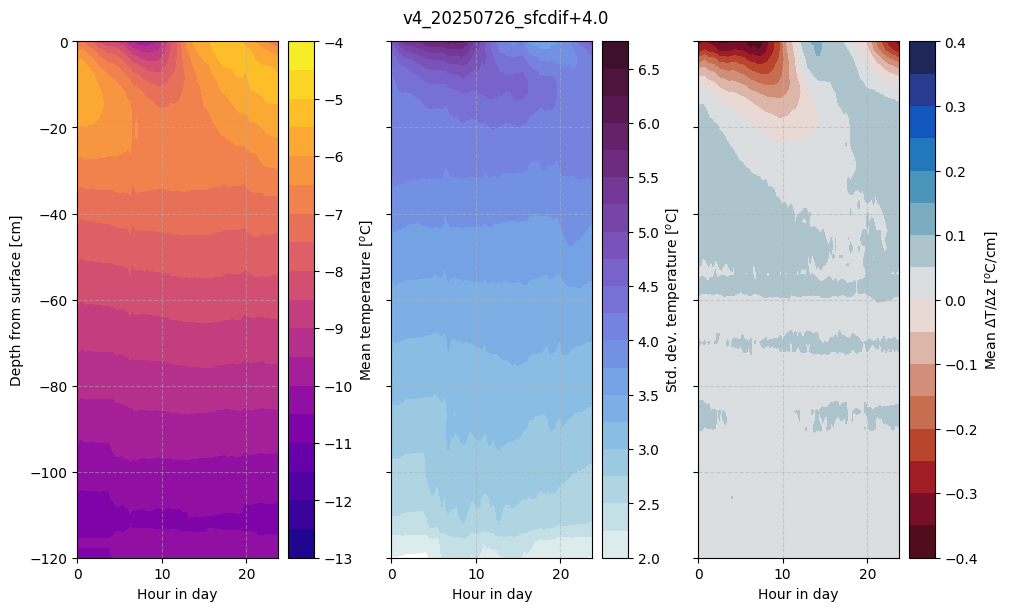

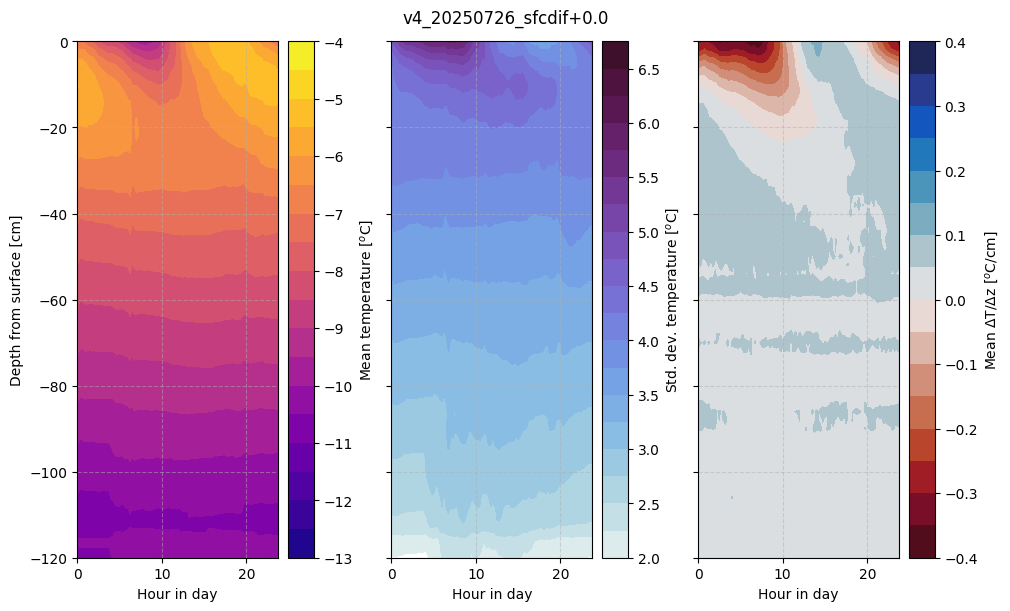

In [11]:
# file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2']
file_versions = ['v2_20250723', 'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0']

for fversion in file_versions:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                         
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])
    dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

    avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
    avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
    std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

    plt_tod = get_simba_time_of_day(simba_data['dates'])


    fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)
    
    cbar_labels = ['Mean temperature [$^o$C]', 'Std. dev. temperature [$^o$C]', 'Mean $\Delta$T/$\Delta$z [$^o$C/cm]']
    levels = [np.arange(-13,-3.6,.5), np.arange(2,7,.25), np.arange(-.4,.41,.05)]
    cmaps = [plt.cm.plasma, cmocean.cm.dense, cmocean.cm.balance_r]
    
    for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_T, std_diurnal_T, avg_diurnal_dTdz])):
        cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var,0,1), levels=levels[i], cmap=cmaps[i])
        plt.colorbar(cb, label=cbar_labels[i], ax=ax)
    
        ax.set_ylim(-120,0)
        
        ax.set_xlabel('Hour in day')
        ax.grid(alpha=.5, ls='--')
    
    axs[0].set_ylabel('Depth from surface [cm]')
    fig.suptitle(fversion)
    plt.show()

### Does melty/not have a bigger impact now?

In [17]:
def get_gpr_melt():
    df = pd.read_csv('/psd3data/arctic/sledd/Melt_Index_despiked_GPR_Raven2024.csv')
    
    gpr_dates = np.array([dt.strptime(d, '%Y-%m-%d %H:%M:%S') for d in df['date'].values])       
    gpr_melt = df['Melt_Index_Normal'].values
    return {'dates':gpr_dates, 'melt':gpr_melt}

In [18]:
def get_gpr_melt_dates(gpr_melt_data, simba_dates, melt_threshold=0.8):

    melty_dates = np.ma.masked_where(gpr_melt_data<melt_threshold, simba_dates)
    melty_day_mn = np.unique([' '.join((str(d.day), str(d.month))) for d in melty_dates[~melty_dates.mask]])
    all_day_mn = np.asarray([' '.join((str(d.day), str(d.month))) for d in simba_dates])
    
    ## inefficient but whatever
    simba_melty_indices = np.zeros(simba_dates.shape)
    
    for md in melty_day_mn:    
        simba_melty_indices[np.where(all_day_mn==md)] = 1

    return simba_melty_indices

In [19]:
def get_subset_dTdz_cycle(melt_indices, data_in, melt_or_dry, dates_in):
    
    melt_masking = {'melt':1, 'dry':0}

    if melt_or_dry not in melt_masking.keys():
        print('Give melt or dry to determine subset')
        return

    melt_val = melt_masking[melt_or_dry]
    
    data_in_subset = dTdz_rel_sfc[np.where(melt_indices==melt_val)[0],:]
    simba_dates_subset = dates_in[np.where(melt_indices==melt_val)[0]]
    
    daily_avgs_subset = get_diurnal_cycle(simba_dates_subset, data_in_subset, stat='mean')
    return daily_avgs_subset


In [20]:
gpr_data = get_gpr_melt()
gpr_seconds = datetimes_to_seconds(gpr_data['dates'])
gpr_melt_idx = interpolate_and_mask(gpr_data['melt'], gpr_seconds, simba_seconds)

In [21]:
simba_melty_idx = get_gpr_melt_dates(gpr_melt_idx, simba_data['dates'])

In [22]:
daily_avgs_dTdz_dry = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'dry', simba_data['dates'])
daily_avgs_dTdz_melty = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'melt', simba_data['dates'])

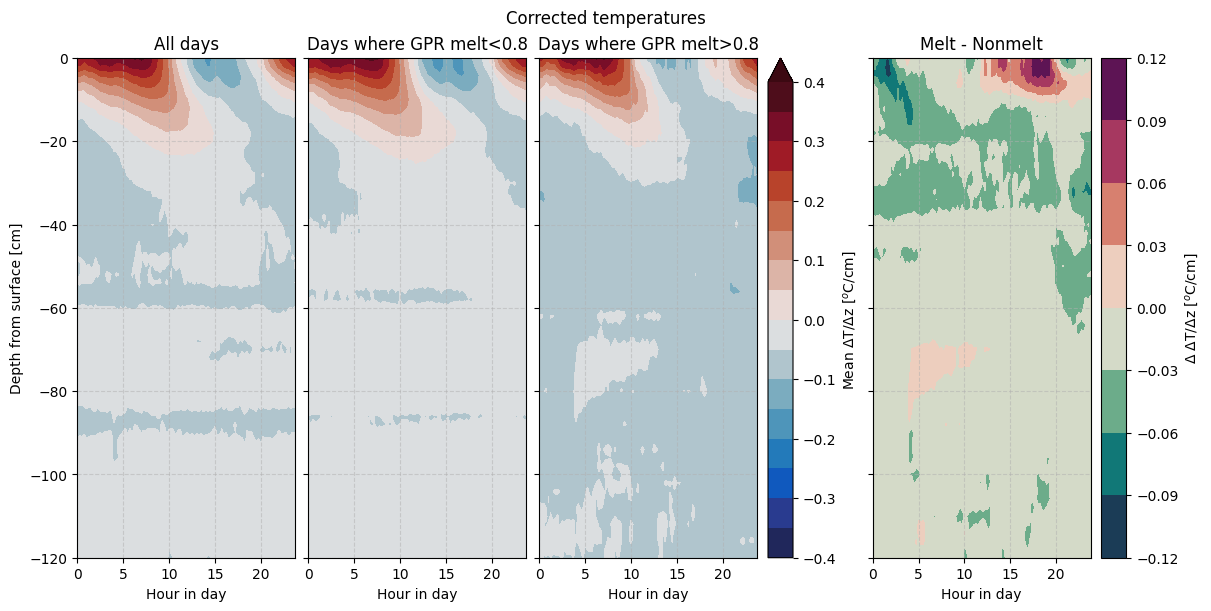

In [101]:
fig, axs = plt.subplots(1,4, figsize=(12,6), constrained_layout=True, sharey=True)

subtitles = ['All days', 'Days where GPR melt<0.8', 'Days where GPR melt>0.8']


for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_dTdz, daily_avgs_dTdz_dry, daily_avgs_dTdz_melty])):
    cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var*-1.,0,1), levels=np.arange(-.4,.41,.05), 
                     cmap=cmocean.cm.balance, extend='max')
    ax.set_title(subtitles[i])

plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[2])

var_dif = daily_avgs_dTdz_melty - daily_avgs_dTdz_dry
cb = axs[3].contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var_dif*-1.,0,1),# levels=np.arange(-.4,.41,.05), 
                 cmap=cmocean.cm.curl)#, extend='max')
plt.colorbar(cb, label='$\Delta$ $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[3])
axs[3].set_title('Melt - Nonmelt')

for ax in axs.ravel():
    ax.set_ylim(-120,0)
    ax.set_xlabel('Hour in day')
    ax.grid(alpha=.5, ls='--')


axs[0].set_ylabel('Depth from surface [cm]')
fig.suptitle('Corrected temperatures')
# plt.tight_layout()
plt.show()

/tmp/ipykernel_762281/41902657.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_762281/41902657.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/tmp/ipykernel_762281/41902657.py:69: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


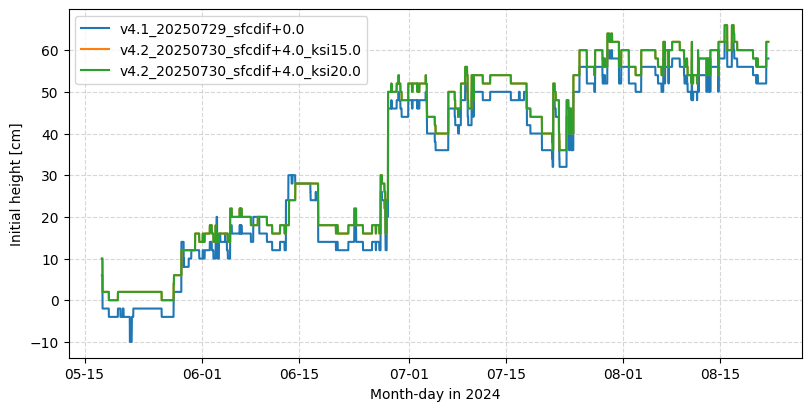

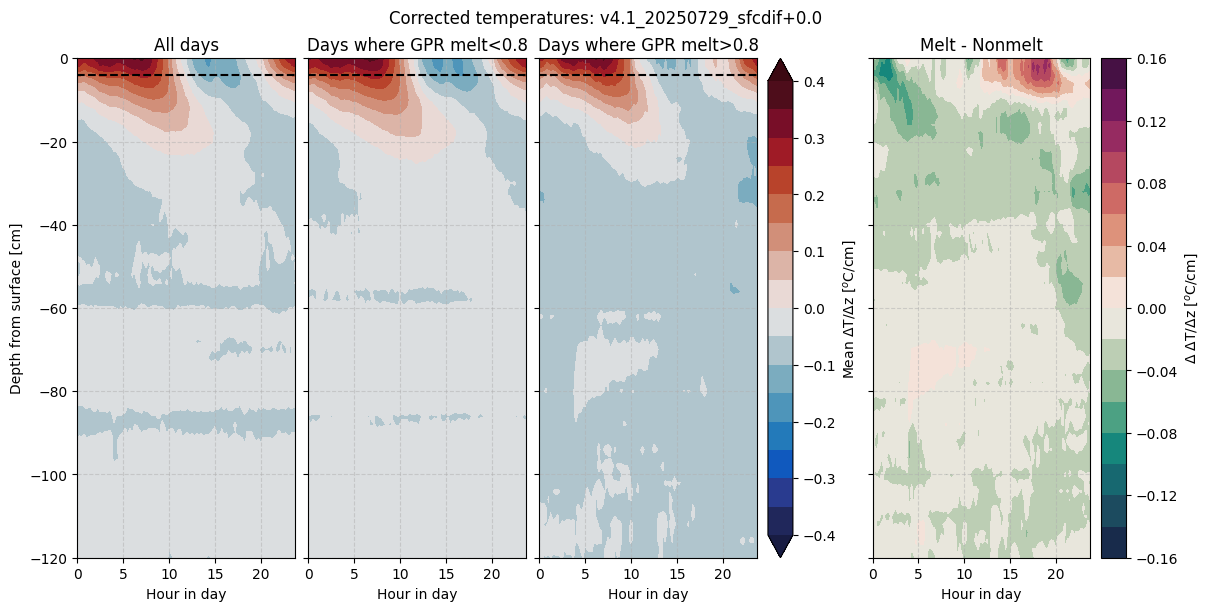

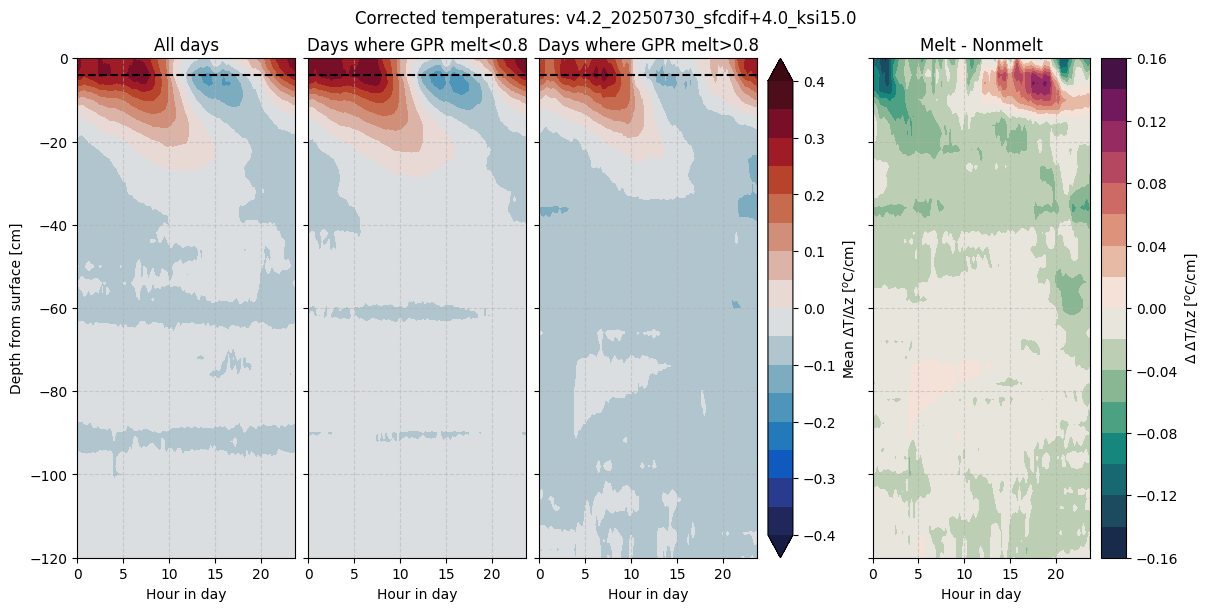

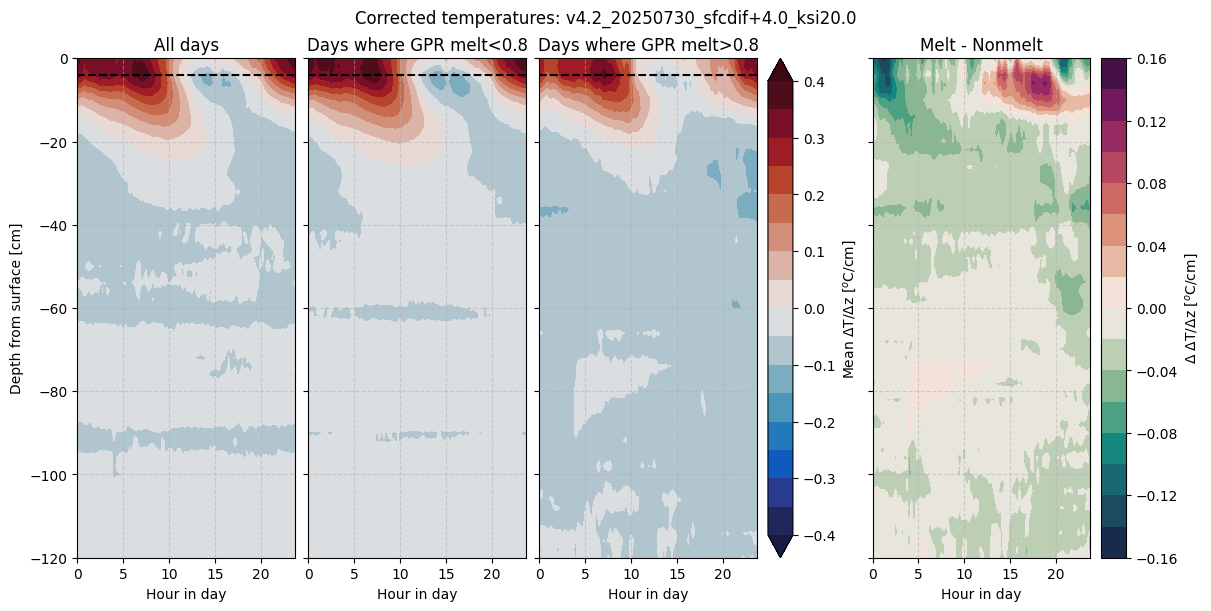

In [102]:
# file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2']
# file_versions = ['v2_20250723', 'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0', 
#                  'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',]
# file_versions = [ 
#                  'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
#                 'v4.2_20250730_sfcdif+4.0_ksi15.0']

file_versions = ['v4.1_20250729_sfcdif+0.0',
                'v4.2_20250730_sfcdif+4.0_ksi15.0', 'v4.2_20250730_sfcdif+4.0_ksi20.0']

fig_sfcs, ax_sfcs = plt.subplots(1, figsize=(8,4), constrained_layout=True)

for fversion in file_versions:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)

    if '+4' in fversion:
        sfc_data += 4.
    elif '+6' in fversion:
        sfc_data += 6.

    ax_sfcs.plot(sfc_dates, sfc_data, label=fversion)
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                         
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])
    dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

    avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
    avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
    std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

    plt_tod = get_simba_time_of_day(simba_data['dates'])


    simba_melty_idx = get_gpr_melt_dates(gpr_melt_idx, simba_data['dates'])
    daily_avgs_dTdz_dry = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'dry', simba_data['dates'])
    daily_avgs_dTdz_melty = get_subset_dTdz_cycle(simba_melty_idx, avg_diurnal_dTdz, 'melt', simba_data['dates'])
    
    fig, axs = plt.subplots(1,4, figsize=(12,6), constrained_layout=True, sharey=True)
    
    subtitles = ['All days', 'Days where GPR melt<0.8', 'Days where GPR melt>0.8']
    
    
    for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_dTdz, daily_avgs_dTdz_dry, daily_avgs_dTdz_melty])):
        cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var*-1.,0,1), levels=np.arange(-.4,.41,.05), 
                         cmap=cmocean.cm.balance, extend='both')
        ax.axhline(y=-4, c='k', ls='--')
        ax.set_title(subtitles[i])
    plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[2])
    
    var_dif = daily_avgs_dTdz_melty - daily_avgs_dTdz_dry
    cb = axs[3].contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(var_dif*-1.,0,1), levels=np.arange(-.16,.161,.02), 
                     cmap=cmocean.cm.curl)#, extend='max')
    plt.colorbar(cb, label='$\Delta$ $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[3])
    axs[3].set_title('Melt - Nonmelt')
    
    for ax in axs.ravel():
        ax.set_ylim(-120,0)
        ax.set_xlabel('Hour in day')
        ax.grid(alpha=.5, ls='--')
    
    axs[0].set_ylabel('Depth from surface [cm]')
    fig.suptitle(f'Corrected temperatures: {fversion}')
    # plt.tight_layout()
    fig.show()

# ax_sfcs.set_xlim(datetime.datetime(2024,6,9),datetime.datetime(2024,6,14))
ax_sfcs.xaxis.set_major_formatter(myFmt)
ax_sfcs.set_xlabel('Month-day in 2024')
ax_sfcs.grid(alpha=.5, ls='--')
ax_sfcs.set_ylabel('Initial height [cm]')
ax_sfcs.legend(loc='best')
plt.show()

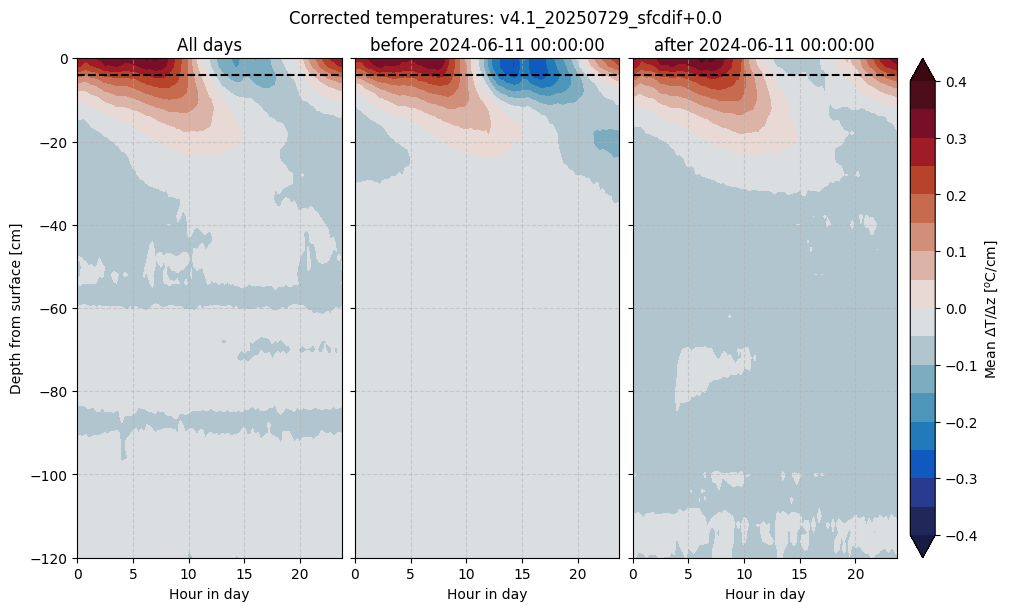

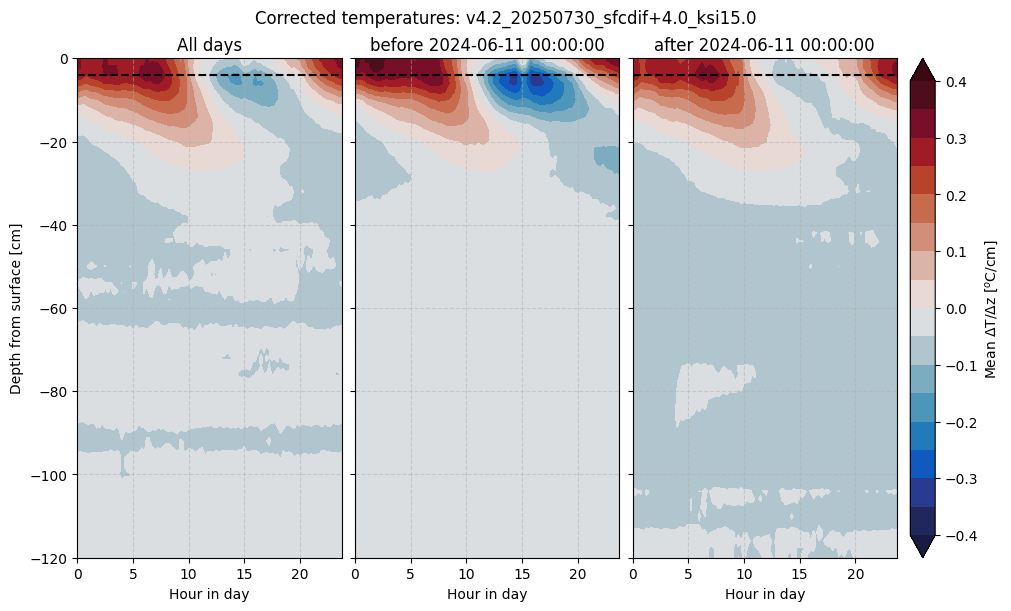

In [98]:
# file_versions = ['v3_20250724', 'v2_20250723', 'v3_20250724_sfcdif+2', 'v2_20250723_sfcdif+2']
# file_versions = ['v2_20250723', 'v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0', 
#                  'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',]
file_versions = ['v4.1_20250729_sfcdif+0.0',
                'v4.2_20250730_sfcdif+4.0_ksi15.0', ]


for fversion in file_versions:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)

    if '+4' in fversion:
        sfc_data += 4.
    elif '+6' in fversion:
        sfc_data += 6.


    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                         
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])
    dTdz_rel_sfc =  np.gradient(temps_rel_sfc, depth_rel_sfc, axis=1)

    avg_diurnal_dTdz = get_diurnal_cycle(simba_data['dates'], dTdz_rel_sfc)
    avg_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc)
    std_diurnal_T = get_diurnal_cycle(simba_data['dates'], temps_rel_sfc, stat='std')

    plt_tod = get_simba_time_of_day(simba_data['dates'])

    date_threshold = datetime.datetime(2024,6,11)
    early_idx = np.where(simba_data['dates']<date_threshold)
    late_idx = np.where(simba_data['dates']>=date_threshold)

    
    daily_avgs_dTdz_early = get_diurnal_cycle(simba_data['dates'][early_idx], dTdz_rel_sfc[early_idx[0],:])
    daily_avgs_dTdz_late = get_diurnal_cycle(simba_data['dates'][late_idx], dTdz_rel_sfc[late_idx[0],:])
    
    fig, axs = plt.subplots(1,3, figsize=(10,6), constrained_layout=True, sharey=True)
    
    subtitles = ['All days', f'before {date_threshold}', f'after {date_threshold}']
    
    
    for i, (ax, var) in enumerate(zip(axs.ravel(), [avg_diurnal_dTdz, daily_avgs_dTdz_early, daily_avgs_dTdz_late])):
        cb = ax.contourf(np.unique(plt_tod), depth_rel_sfc, np.swapaxes(-var,0,1), levels=np.arange(-.4,.41,.05), 
                         cmap=cmocean.cm.balance, extend='both')
        ax.set_title(subtitles[i])
        ax.axhline(y=-4, c='k', ls='--')
        ax.set_ylim(-120,0)
        ax.set_xlabel('Hour in day')
        ax.grid(alpha=.5, ls='--')

    plt.colorbar(cb, label='Mean $\Delta$T/$\Delta$z [$^o$C/cm]', ax=axs[-1])
    
    axs[0].set_ylabel('Depth from surface [cm]')
    fig.suptitle(f'Corrected temperatures: {fversion}')
    # plt.tight_layout()
    plt.show()



#### compare surface heights to uncorrected dT/dz (and dT/dt?)

In [36]:
def load_ogre_surfaces():
    ogre_surface_out = {}

    for ogre in ['rav1_south','rav2_origin','rav3_west']:
        df = pd.read_csv('/psd3data/arctic/sledd/Raven_OGRE/'+ogre+'.csv')
        
        ogre_date = np.array([dt.strptime(d, '%m/%d/%y %H:%M') for d in df['Datetime'].values])       
        ogre_sfc = df[' Average Ant. Height [m]'].values
        ogre_surface_out[ogre] = {'dates':ogre_date, 'sfc':ogre_sfc}
    return ogre_surface_out

In [37]:
uncorrected_simba_data = load_uncorrected_simba()

In [38]:
uncorr_dTdz = np.gradient(uncorrected_simba_data['temperature'], uncorrected_simba_data['height'], axis=1)

uncorr_seconds = datetimes_to_seconds(uncorrected_simba_data['dates'])
uncorr_dTdt = np.gradient(uncorrected_simba_data['temperature'], uncorr_seconds, axis=0)

In [39]:
sleigh_vars = ['up_short_hemisp_qc','up_long_hemisp_qc','down_short_hemisp_qc','down_long_hemisp_qc','subsurface_heat_flux_A_qc',
                  'subsurface_heat_flux_B_qc','skin_temp_surface_qc','temp_qc','snow_depth_qc','zenith_true_qc',
                  'down_short_diffuse','down_short_direct','up_short_hemisp','up_long_hemisp','down_short_hemisp','down_long_hemisp',
                  'snow_depth','temp','brightness_temp_surface','skin_temp_surface','subsurface_heat_flux_A','subsurface_heat_flux_B',
                  'subsurface_heat_flux_C','zenith_true','snow_gpr_dist','base_time','time']

asfs_data_lev2 = load_raven_sleigh_data(sleigh_vars)

In [40]:
ogre_surface = load_ogre_surfaces()

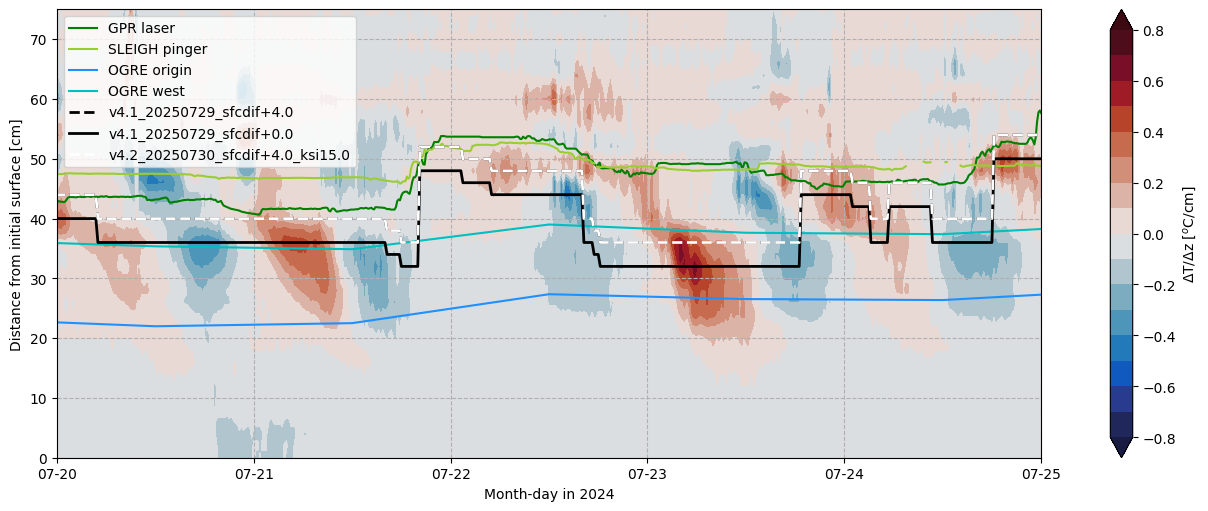

In [41]:
# file_versions = ['v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0', 
#                  'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0']
file_versions = [ 
                 'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
                'v4.2_20250730_sfcdif+4.0_ksi15.0']

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)

cmap = plt.cm.RdPu
# cmap = cmocean.cm.amp
cb = ax.contourf(uncorrected_simba_data['dates'], uncorrected_simba_data['height'], np.swapaxes(-1*uncorr_dTdz,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.8,.81,.1), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta$T/$\Delta$z [$^o$C/cm]')

ax.grid(ls='--')

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)
    
for fversion, c, ls in zip(file_versions,['k','k','w','w'],['--','-','--','-']):
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    if '+4' in fversion:
        sfc_data += 4.
    ax.plot(sfc_dates, sfc_data, label=fversion, c=c, lw=2, ls=ls)



ax.legend(loc='upper left')

ax.set_ylabel('Distance from initial surface [cm]')
# ax.set_ylim(-20, 75)
ax.set_ylim(0, 75)

ax.set_xlim(datetime.datetime(2024,7,20),datetime.datetime(2024,7,25))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

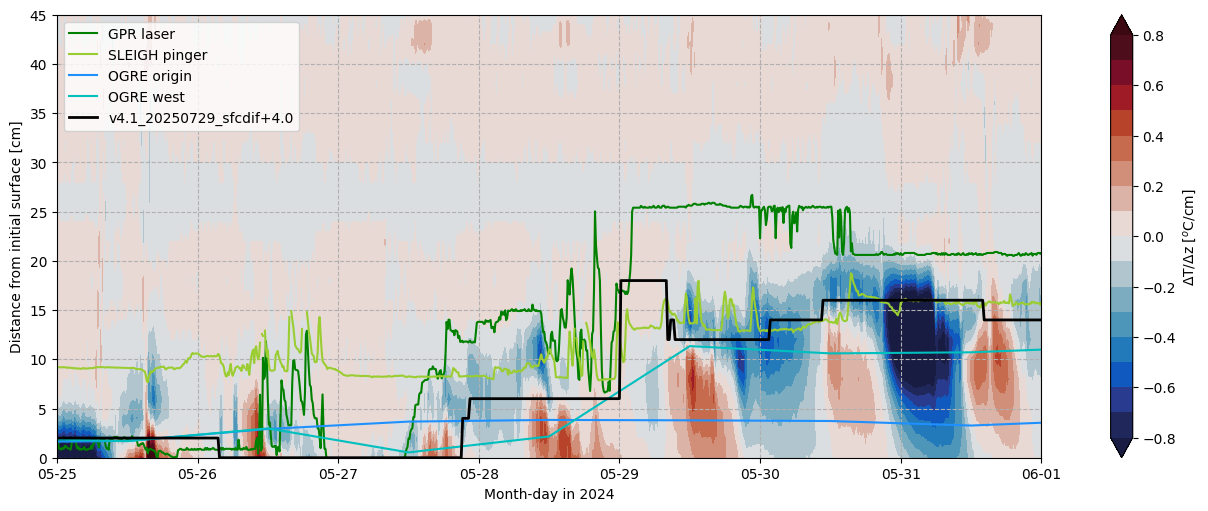

In [42]:
file_versions = ['v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0', 
                 'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0']

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)

cmap = plt.cm.RdPu
# cmap = cmocean.cm.amp
cb = ax.contourf(uncorrected_simba_data['dates'], uncorrected_simba_data['height'], np.swapaxes(uncorr_dTdz,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.8,.81,.1), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta$T/$\Delta$z [$^o$C/cm]')

ax.grid(ls='--')

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)
    
fversion = 'v4.1_20250729_sfcdif+4.0'
sfc_dates, sfc_data = open_simba_sfc_file(fversion)
if '+4' in fversion:
    sfc_data += 4.

mean_early_sfc_idx = np.where((sfc_dates>datetime.datetime(2024,5,17))&(sfc_dates<datetime.datetime(2024,5,18)))[0]
sfc_data[np.where(sfc_dates<datetime.datetime(2024,5,18))] = np.ma.mean( sfc_data[mean_early_sfc_idx])
ax.plot(sfc_dates, sfc_data, label=fversion, c='k', lw=2)



ax.legend(loc='upper left')

ax.set_ylabel('Distance from initial surface [cm]')
# ax.set_ylim(-20, 75)
ax.set_ylim(0, 45)

ax.set_xlim(datetime.datetime(2024,5,25),datetime.datetime(2024,6,1))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

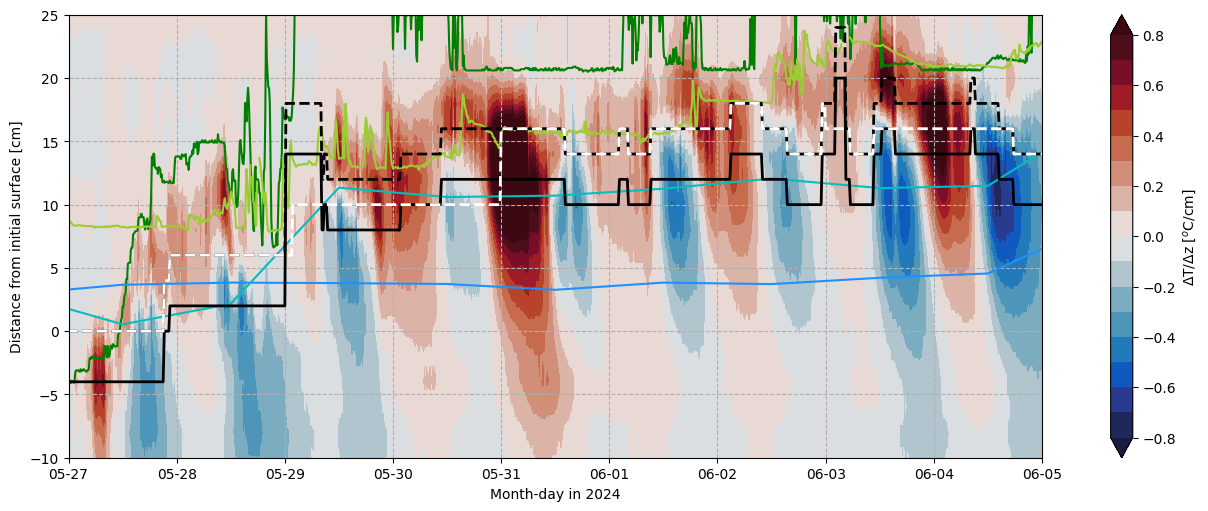

In [86]:
file_versions = [ 
                 'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
                'v4.2_20250730_sfcdif+4.0_ksi15.0']

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)

cmap = plt.cm.RdPu
# cmap = cmocean.cm.amp
cb = ax.contourf(uncorrected_simba_data['dates'], uncorrected_simba_data['height'], np.swapaxes(-uncorr_dTdz,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.8,.81,.1), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta$T/$\Delta$z [$^o$C/cm]')

ax.grid(ls='--')

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)
    
for fversion, c, ls in zip(file_versions,['k','k','w','w'],['--','-','--','-']):
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    if '+4' in fversion:
        sfc_data += 4.
    ax.plot(sfc_dates, sfc_data, label=fversion, c=c, lw=2, ls=ls)



# ax.legend(loc='upper right')

ax.set_ylabel('Distance from initial surface [cm]')
# ax.set_ylim(-20, 75)
ax.set_ylim(-10, 25)

ax.set_xlim(datetime.datetime(2024,5,27),datetime.datetime(2024,6,5))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

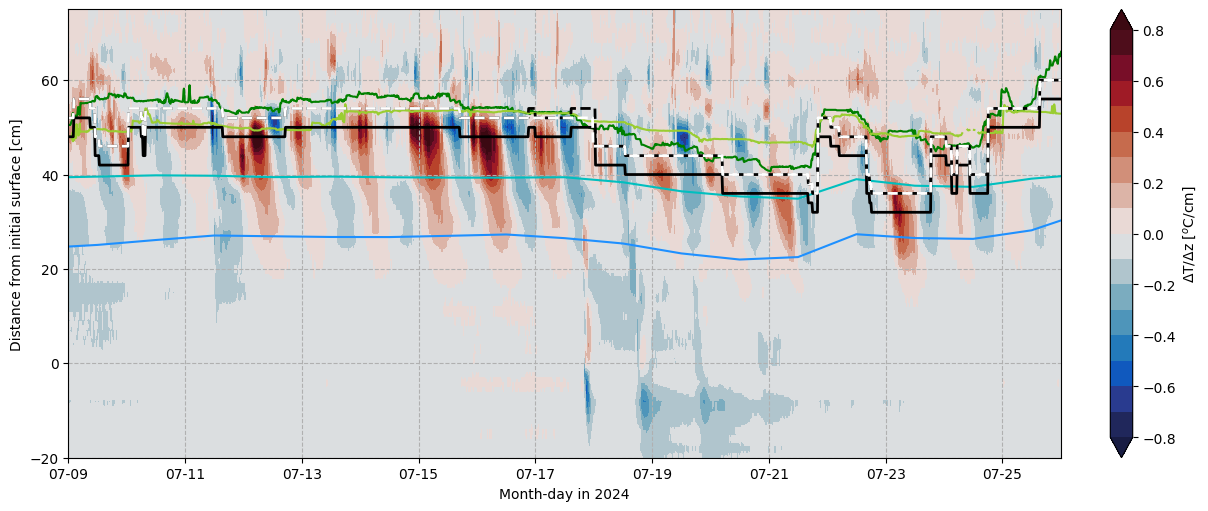

In [77]:
file_versions = [ 
                 'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
                'v4.2_20250730_sfcdif+4.0_ksi15.0']

fig, ax = plt.subplots(1, figsize=(12,5), constrained_layout=True, sharex=False)

cmap = plt.cm.RdPu
# cmap = cmocean.cm.amp
cb = ax.contourf(uncorrected_simba_data['dates'], uncorrected_simba_data['height'], np.swapaxes(-uncorr_dTdz,0,1),
                cmap=cmocean.cm.balance, levels=np.arange(-.8,.81,.1), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta$T/$\Delta$z [$^o$C/cm]')

ax.grid(ls='--')

ax.plot( asfs_data_lev2['dates'], (asfs_data_lev2['snow_gpr_dist'][0]-asfs_data_lev2['snow_gpr_dist'])*100., label='GPR laser', c='green')
ax.plot( asfs_data_lev2['dates'], asfs_data_lev2['snow_depth'], label='SLEIGH pinger', c='yellowgreen')

for ogre, c in zip(['rav2_origin','rav3_west'],['dodgerblue', 'c']):
    ax.plot(ogre_surface[ogre]['dates'], (ogre_surface[ogre]['sfc'][0]-ogre_surface[ogre]['sfc'])*100., 
            label='OGRE '+ogre.split('_')[-1], c=c)
    
for fversion, c, ls in zip(file_versions,['k','k','w','w'],['--','-','--','-']):
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    if '+4' in fversion:
        sfc_data += 4.
    ax.plot(sfc_dates, sfc_data, label=fversion, c=c, lw=2, ls=ls)



# ax.legend(loc='upper right')

ax.set_ylabel('Distance from initial surface [cm]')
ax.set_ylim(-20, 75)

ax.set_xlim(datetime.datetime(2024,7,9),datetime.datetime(2024,7,26))
ax.xaxis.set_major_formatter(myFmt)
ax.set_xlabel('Month-day in 2024')

# axs[1].set_xlim(plt_times_not_smooth[0], plt_times_not_smooth[-1])
# plt.savefig('/home/asledd/ICECAPS/keff_retrieval/Raven_dtdz-flux-profile-timeseries_skinT_3level-smoothing-window.png', dpi=250)
# plt.savefig(plrams_fpath+'SIMBA_uncorrected_T_sfc-comparisons.png', dpi=300)

plt.show()

### remake some figures for paper from Raven_surface_comparisons.ipynb

In [95]:
def detrend_temps_rel_to_sfc(temps_rel_to_sfc):
    x = np.arange(temps_rel_to_sfc.shape[0])

    slopes_with_depth = []
    
    for i in range(temps_rel_to_sfc.shape[1]):
        y = temps_rel_to_sfc[:,i]
    
        try:
            coeff = np.ma.polyfit(x, y, 2)
        except:
            detrend_temps = np.ma.concatenate( (detrend_temps, np.full(x.shape, np.nan)[:, np.newaxis]), axis=1 )
            slopes_with_depth.append(np.nan)
            continue
        # no need to use the original x values here just for visualizing the polynomial
        x_poly = np.linspace(x.min(), x.max())
        y_poly = np.polyval(coeff, x_poly)
        
        # we need the original x values here, so we can remove the trend from all points
        trend = np.polyval(coeff, x)
        t_detrend = y - trend
        # note that simply subtracting the trend might not be enough for other data sets
        slopes_with_depth.append(coeff[0])
            
        if i==0:
            detrend_temps = t_detrend[:, np.newaxis]
            ## check detrending
            # plt.plot(x, y, label='raw')
            # plt.plot(x, trend, label='trend')
            # plt.plot(x, t_detrend, label='detrended')
            # plt.legend(loc='best')
            # plt.show()
    
        else:
            detrend_temps = np.ma.concatenate( (detrend_temps, t_detrend[:, np.newaxis]), axis=1 )
    
        # print(i, coeff[0])
    
    
    return np.ma.masked_invalid(detrend_temps)

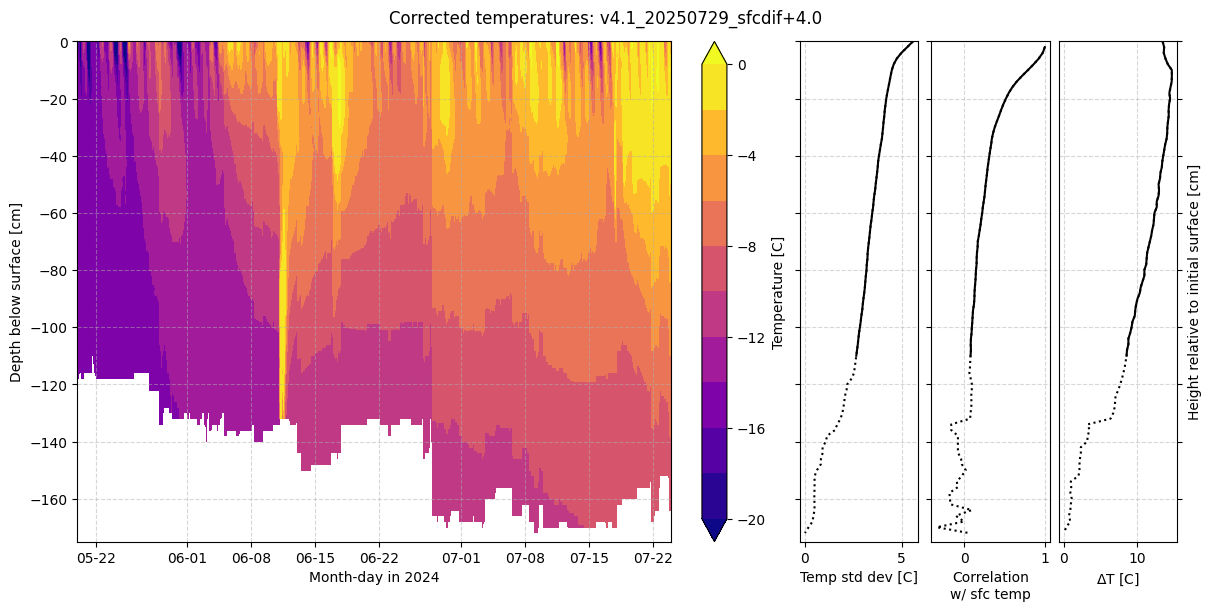

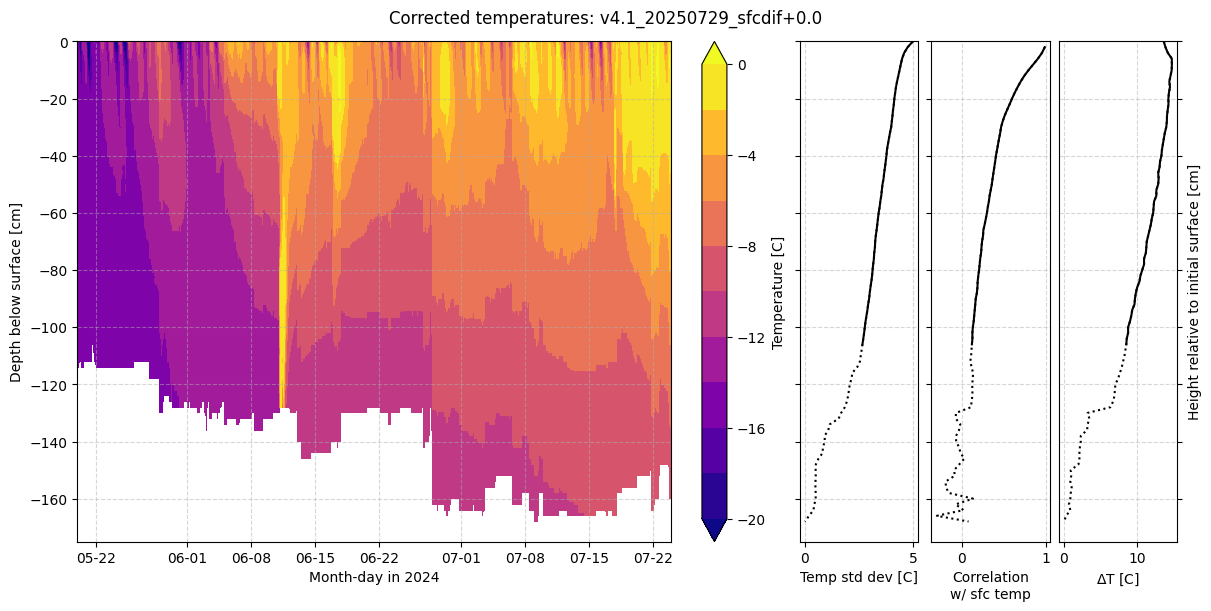

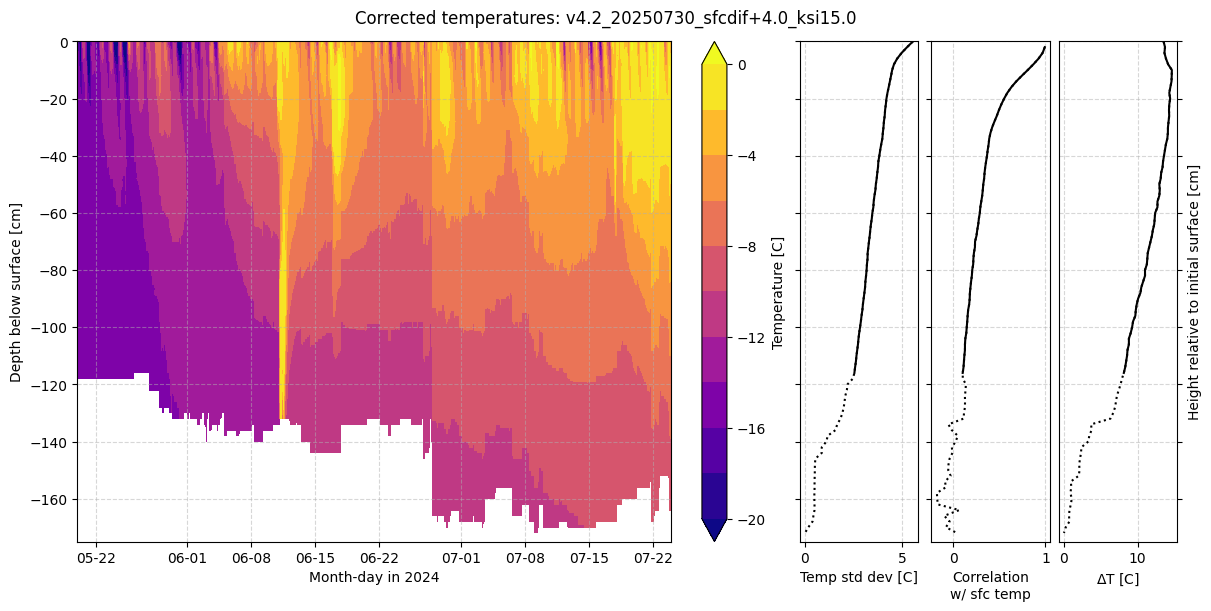

In [163]:
# file_versions = ['v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0', 
#                  'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0']
file_versions = [ 
                 'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0',
                'v4.2_20250730_sfcdif+4.0_ksi15.0']

for fversion in file_versions[:]:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    if '+4' in fversion:
        sfc_data += 4.
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                  
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])



    temp_counts = temps_rel_sfc.count(axis=0)
    
    ## std dev w/ depth
    temp_std_profile = temps_rel_sfc.std(axis=0)
    
    l = temps_rel_sfc.count(axis=0)[0]
    temp_std_full = np.ma.masked_where(temp_counts<l, temp_std_profile)
    
    
    # warming relative to surface - also test warming at each level?
    dT_dt_rel_to_sfc = temps_rel_sfc[1:,:] - temps_rel_sfc[:-1,:]
    dT_dt_rel_to_sfc = dT_dt_rel_to_sfc.sum(axis=0)

    detrend_temps = detrend_temps_rel_to_sfc(temps_rel_sfc)
    detrend_corr = np.ma.corrcoef(detrend_temps[:,0], detrend_temps[:,1:].T)[0][1:]

    ## SHOULD SAVE THIS DATA AND THEN PLOT OUTSIDE OF THIS LOOP!

    fig, axs = plt.subplots(1,4, figsize=(12,6), sharey=True, 
                            gridspec_kw=dict(width_ratios=[5,1,1,1]), constrained_layout=True)
    
    cb = axs[0].contourf(simba_data['dates'], depth_rel_sfc, np.swapaxes(temps_rel_sfc,0,1), cmap='plasma',
                        levels=np.arange(-20,0.1,2), extend='both')
    plt.colorbar(cb, label='Temperature [C]', ax=axs[0])
    
    labels = ['Temp std dev [C]','Correlation\nw/ sfc temp','$\Delta$T [C]']
    for i, (ax, var) in enumerate(zip(axs.ravel()[1:], [temp_std_profile, detrend_corr, dT_dt_rel_to_sfc])):
    
        # print(var)
        if i==1:
            ax.plot(var, depth_rel_sfc[1:],ls=':', c='k')
            ax.plot(detrend_corr[~temp_std_full[1:].mask], depth_rel_sfc[1:][~temp_std_full[1:].mask], c='k')
        else:
            ax.plot(var, depth_rel_sfc, ls=':', c='k')
            ax.plot(var[~temp_std_full.mask], depth_rel_sfc[~temp_std_full.mask], c='k')
    
        ax.set_xlabel(labels[i])
        ax.grid(alpha=.5, ls='--')

    fig.suptitle(f'Corrected temperatures: {fversion}')

    axs[0].set_ylabel('Depth below surface [cm]')
    axs[0].xaxis.set_major_formatter(myFmt)
    axs[0].set_xlabel('Month-day in 2024')
    
    axs[-1].yaxis.set_label_position("right")
    axs[-1].yaxis.tick_right()
    axs[-1].set_ylabel('Height relative to initial surface [cm]')
    
    axs[0].set_ylim(-175,0)
    axs[0].grid(alpha=.5, ls='--')
    plt.show()

Choice of surface has limited impact on these figures/conclusions, which is good

## calculate storage from these different surfaces for michael

In [82]:
def interpolate_snowpit_densities(init_density, final_density, out_seconds):

    ## datetimes are from install and demob
    st_seconds = datetimes_to_seconds([datetime.datetime(2024,5,15)])
    en_seconds = datetimes_to_seconds([datetime.datetime(2024,8,19)])

    f_density = interpolate.interp1d([st_seconds[0], en_seconds[0]],[init_density, final_density])
    density_timeseries = f_density(out_seconds)

    return density_timeseries

In [83]:
def calculate_storage(temps_rel_to_sfc, seconds_in, sub_depths, d_layer=20):

    c_i = 2.1*10**-3 # MJ kg-1 C-1
    d = 0.02 # m
    
    # from snow pits at install and demob
    # now averaged in upper 20/30 cm
    # should just the average be used instead of range?
    if d_layer==20:
        rho_lo = interpolate_snowpit_densities(238, 229, simba_seconds)
        rho_hi = interpolate_snowpit_densities(328, 379, simba_seconds)
    elif d_lay==30:
        rho_lo = interpolate_snowpit_densities(242, 226, simba_seconds)
        rho_hi = interpolate_snowpit_densities(325, 387, simba_seconds)

    else:
        print('go calculate average density over new d_layer or choose 20 or 30 cm')
        return
    avg_temps = np.ma.copy(temps_rel_to_sfc)[:,np.where(sub_depths>=-d_layer)[0]].mean(axis=1)
    avg_temp_diff = avg_temps[2:] - avg_temps[:-2]
    time_diff = 2.*(seconds_in[2:] - seconds_in[:-2])
    
    # 10^6 to convert from MJ to J
    storage_avg_lo = 10.**6*c_i*rho_lo[1:-1]*0.2*avg_temp_diff/time_diff
    storage_avg_hi = 10.**6*c_i*rho_hi[1:-1]*0.2*avg_temp_diff/time_diff

    return {'high_density':storage_avg_hi, 'low_density':storage_avg_lo}

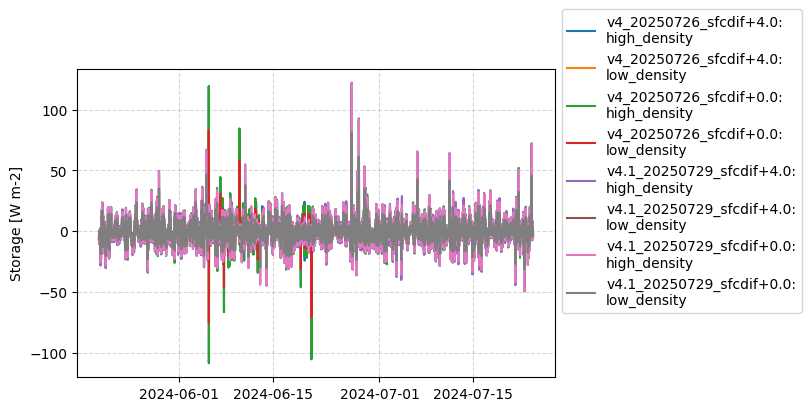

In [90]:
file_versions = ['v4_20250726_sfcdif+4.0', 'v4_20250726_sfcdif+0.0', 
                 'v4.1_20250729_sfcdif+4.0', 'v4.1_20250729_sfcdif+0.0']

fig_sfcs, ax_sfcs = plt.subplots(1, figsize=(8,4), constrained_layout=True)

for fversion in file_versions[:]:
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                  
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])


    ## now calculate storage
    simba_storage = calculate_storage(temps_rel_sfc, simba_seconds, depth_rel_sfc, d_layer=20)
    for key in simba_storage:
        plt.plot(simba_data['dates'][1:-1], simba_storage[key], label=f'{fversion}:\n{key}')

plt.ylabel('Storage [W m-2]')
plt.grid(alpha=.5, ls='--')
plt.legend(loc='center left', bbox_to_anchor=(1,.7))
plt.show()
    # plt.show()

Storage is calculated using <eqtn> where <variables are defined>. Density is found by linearly interpolating between density measurements from snowpits during the instrument installation and demobilization. Ranges are found from the maximum and minium values at the beginning and of the time period averaged over the upper <20 or 30> cm of snow. Temperatures are from the thermistor string isntalled within meters of the SLEIGH. The snow surface is identified by the maximum variance of dT/dz in runnig 24 hour windows. A correction for solar bias was identified and corrected for assuming 50% of incoming solar radiation is in the near infrared and absorbed within milimeters of the surface and the rest of the solar radiation decays exponentially. Further details will be published in a forthcoming manuscript.

In [ ]:
fversion = 'v4.1_20250729_sfcdif+4.0'

storage_data = {}

for depth in [20, 30]:
    storage_data[depth] = {}
    
    simba_data = open_corrected_simba_temps(fversion)
    sfc_dates, sfc_data = open_simba_sfc_file(fversion)
    
    sfc_seconds = datetimes_to_seconds(sfc_dates)
    simba_seconds = datetimes_to_seconds(simba_data['dates'])
                                  
    simba_data['surface'] = interpolate_and_mask(sfc_data, sfc_seconds, simba_seconds)

    depth_rel_sfc, temps_rel_sfc = make_temps_rel_to_sfc(simba_data['height'], simba_data['temperature'], simba_data['surface'])


    ## now calculate storage
    simba_storage = calculate_storage(temps_rel_sfc, simba_seconds, depth_rel_sfc, d_layer=depth)

    storage_data[depth]

In [ ]:
## Saving for michael

with open('Raven_2024_20cm_storage_range_20250416_maxheight.csv', 'w', ) as myfile:
    wr = csv.writer(myfile, quoting=csv.QUOTE_ALL)
    myfile.write("{},{}\n".format("Dates", "Low storage [W m-2]", "High storage [W m-2]", "Low Density [kg m-3]", "High Density [kg m-3]"))
    for item1, item2, item3, item4, item5 in zip(simba_dates[1:-1], storage_avg_lo, storage_avg_hi, rho_lo, rho_hi):
        wr.writerow([item1, item2, item3, item4, item5])
        